In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [4]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [5]:
rvir = 0.5
c = 4
r_s = rvir/c
print(r_s)
rho0 = rho_s(10**13, r_s, c)
print(rho0)

0.125
503357512733780.2


In [6]:
def nfw_ft_analytical(k_values, r_s, rvir):
    fourier_transform = np.zeros_like(k_values)
    
    c = rvir/r_s
    print(c)
    for i, k in enumerate(k_values):
        kr_s = k * r_s
        Si_c, Ci_c = sici((1+c)*kr_s)
        Si, Ci = sici(kr_s)
        f = 1/(np.log(1+c) - c/(1+c))
        term1 = np.sin(kr_s) * (Si_c - Si)
        term2 = np.cos(kr_s) * (Ci_c - Ci)
        term3 = -np.sin(c*kr_s)/((1+c)*kr_s)
        fourier_transform[i] = f*(term1 + term2 + term3)
    
    return fourier_transform

In [7]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
uk_nfw = nfw_ft_analytical(ks, 0.125, 0.5)
uk_nfw2 = nfw_ft_analytical(ks, 0.05, 0.5)

4.0
10.0


In [19]:
logMmin = 13.0
logMmax = 13.1


odir1 = "/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/number_density"
#odir1 = "/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir"
fname1 = f"{odir1}/sat_sum/logM_range/logM{logMmin}-{logMmax}.pickle"
fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/n200.pickle"


#fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/tng_sats_in_r0.5.pickle"
fname1 = f"{odir1}/sat_sum/logM_range/logM{logMmin}-{logMmax}.pickle"

fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w2_in_rs.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum = pickle.load(f)

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_n200_n100.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_c8_rvir0.5_rvir1_n200.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_rvir1_n200.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w1_w2.pickle"

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/tng_sats_in_r0.5.pickle"
fname2 = f"{odir1}/sat/logM_range/logM{logMmin}-{logMmax}.pickle"

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_n200_rmax1.pickle"

fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w2_in_rs.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal = pickle.load(f)


In [11]:
logMmin = 13.0
logMmax = 13.1


odir1 = "/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir/number_density"
#odir1 = "/cosma/home/dp004/dc-zhan5/paper1/ps_data/snap40/mvir"
fname1 = f"{odir1}/sat_sum/logM_range/logM{logMmin}-{logMmax}.pickle"
fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/n200.pickle"


#fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/tng_sats_in_r0.5.pickle"
fname1 = f"{odir1}/sat_sum/logM_range/logM{logMmin}-{logMmax}.pickle"

fname1 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_n200.pickle"
#fname1 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w2_in_rs.pickle"
with open(fname1, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_sum1 = pickle.load(f)

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_n200_n100.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_c8_rvir0.5_rvir1_n200.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_rvir1_n200.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w1_w2.pickle"

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/tng_sats_in_r0.5.pickle"
fname2 = f"{odir1}/sat/logM_range/logM{logMmin}-{logMmax}.pickle"

#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/c4_rvir0.5_n200_rmax1.pickle"


fname2 = f"{odir1}/sat_nfw_sum/logM_range/logM{logMmin}-{logMmax}/n200.pickle"
#fname2 = f"{odir1}/sat_nfw/logM_range/logM{logMmin}-{logMmax}/weighted_c4_rvir0.5_n200/w2_in_rs.pickle"
with open(fname2, "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk13_gal1 = pickle.load(f)


In [20]:
Pk13_gal.attrs["shotnoise"]

396.9163614438873

In [21]:
logks_tng = np.log10(Pk13_sum["k"])

In [22]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [36]:
uk2_13 = compute_uk2(Pk13_gal, Pk13_sum)
uk2_13_1 = compute_uk2(Pk13_gal1, Pk13_sum1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


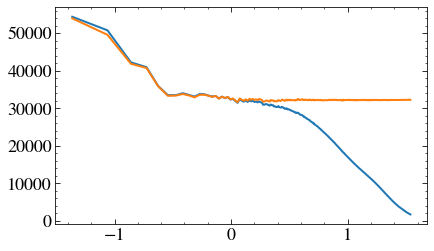

In [24]:
plt.plot(logks_tng, Pk13_gal["power"])
plt.plot(logks_tng, Pk13_sum["power"])

In [25]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
rs = 0.125
rvir = 0.5
rvir2 = rvir
c = 4
c2 = 80
uk_nfw = nfw_ft_analytical(ks, rvir/c, rvir)
uk_nfw2 = nfw_ft_analytical(ks, rvir2/c2, rvir2)

4.0
80.0


In [26]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [27]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
rs1 = 0.125
rvir = 0.5
rvir2 = rvir
c1 = 4
c2 = 80

rho01 = rho_s(10**13, rs1, c1)

rho01 = rho_s(10**13, rs1, c1)
uk1 = nfw_ft_numerical(ks, rho0, r_s,rvir, rmax=0.9)
uk2 = nfw_ft_numerical(ks, rho0, r_s,rvir, rmax=0.9)

In [40]:

c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=0.5)

In [29]:
uk1 = nfw_ft_numerical(ks, rho0, r_s,rvir, rmax=0.8)
uk2 = nfw_ft_numerical(ks, rho0, r_s,rvir, rmax=1.2)

In [30]:
from colossus.halo import profile_nfw
from colossus.cosmology import cosmology

cosmo = cosmology.setCosmology('planck15')

def cmpc_2_pkpc(r_cmpc_h, z=1.5):
    # original is pkpc/h
    # I want to convert to cMpc/h

    r_kpc_h = r_cmpc_h * 1e3

    #print(r_kpc_h)

    r_pkpc_h = r_kpc_h/(1+z)
    

    return r_pkpc_h

def convert_rho_units(rho, z=1.5):
    # rho is in units of Msun h^2 / pkpc^3
    # (Msun / h) / (pkpc/h)^3

    rho_mpc_h = rho/((1+z)/1e3)**3

    return rho_mpc_h


def nfw_ft_numerical_from_colossus(k_values, mvir, conc, rmax, z=1.5):


    p_nfw = profile_nfw.NFWProfile(M = mvir, c = conc, z = z, mdef = 'vir')

    #R_pkpc_h = mass_so.M_to_R(mvir, z=z, mdef='vir')
    #rvir = pkpc_2_cmpc(R_pkpc_h)

    #rmax_pkpc_h = cmpc_2_pkpc(rmax) 

    def rho(r):
        rho1 = p_nfw.density(r)
        rho1 = convert_rho_units(rho1)
        return rho1


    def integrand_func(r_cmpc_h):
        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) * np.sin(k * r_cmpc_h) / (k * r_cmpc_h)
        return integrand

    def integrand_norm(r_cmpc_h):

        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) 
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [24]:
uk_colossus = nfw_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=1)

In [33]:
uk1 = nfw_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=0.7)
uk2 = nfw_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=1.1)

In [31]:
from colossus.halo import profile_einasto
from colossus.halo import profile_diemer23
from colossus.halo import profile_dk14
def einasto_ft_numerical_from_colossus(k_values, mvir, conc, rmax, z=1.5):
    p_einasto = profile_einasto.EinastoProfile(M = mvir, c = conc, z = z, mdef = 'vir')

    p_einasto = profile_diemer23.ModelAProfile(M = 1e13, c = c, z = 1.5, mdef = 'vir', alpha=0.1)

    #p_einasto = profile_dk14.DK14Profile(M = 1e13, c = c, z = 1.5, mdef = 'vir', alpha=0.1)
    #R_pkpc_h = mass_so.M_to_R(mvir, z=z, mdef='vir')
    #rvir = pkpc_2_cmpc(R_pkpc_h)

    #rmax_pkpc_h = cmpc_2_pkpc(rmax) 

    def rho(r):
        rho1 = p_einasto.density(r)
        rho1 = convert_rho_units(rho1)
        return rho1


    def integrand_func(r_cmpc_h):
        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) * np.sin(k * r_cmpc_h) / (k * r_cmpc_h)
        return integrand

    def integrand_norm(r_cmpc_h):

        r_pkpc_h = cmpc_2_pkpc(r_cmpc_h)
        integrand = 4*np.pi* r_cmpc_h**2 * rho(r_pkpc_h) 
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [85]:
uk_einasto = einasto_ft_numerical_from_colossus(ks, mvir=1e13, conc=4, rmax=1.5)

In [86]:
c = rvir/rs
print(c)

4.0


In [49]:
def weight_func(x):
    logx = np.log10(x)
    # if (x > 0.2) & (x < 0.8):
    #     logy = 0.75*(logx-3.1)**2 -0.65
    if x < 0.125:
        y = 8
        
    else:
        #logy = 0
        y = 1

    # if (x > 0.2) & (x < 0.8):
    #     logy = 0.75*(logx-3.1)**2 -0.65
    #     y = 10**logy
    # else:
    #     y = 1
    #logy = np.zeros(len(bin_centers))
    

    #logy = 0.7*(logx-3.2)**2 -0.7
    #mask = x > 100
    return y

In [50]:
def combined_profile(r, rho0, rs):
    return nfw_profile(r, rho0, rs)*weight_func(r)

In [51]:
def combined_numerical_ft(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * combined_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax, limit=300)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax, limit=300)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [52]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=4
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk2= combined_numerical_ft(ks, rho0, rs,rvir, rmax=0.5)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h Mpc^{-1}]})$')

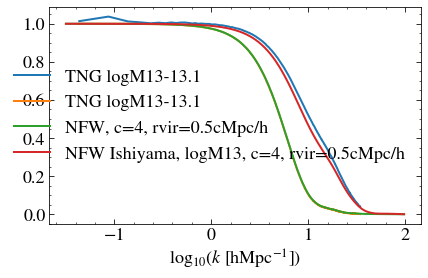

In [53]:
plt.plot(logks_tng, uk2_13, label="TNG logM13-13.1")
plt.plot(logks_tng, uk2_13_1, label="TNG logM13-13.1")
#plt.plot(logks, uk_nfw**2, label=f"NFW Ishiyama, logM13, c={c}, rvir={rvir}cMpc/h")

plt.plot(logks, uk_numerical**2, label=f"NFW, c={c}, rvir={rvir}cMpc/h")

#plt.plot(logks, uk_colossus**2, label=f"NFW Ishiyama, logM13, c={c}, rvir={rvir}cMpc/h")




#plt.plot(logks, uk_einasto**2, label=f"Diemer, logM13, c={c}, rvir={rvir}cMpc/h")


#plt.plot(logks, uk1**2, label=f"NFW Ishiyama, logM13, c={c}, rvir={rvir}cMpc/h")

plt.plot(logks, uk2**2, label=f"NFW Ishiyama, logM13, c={c}, rvir={rvir}cMpc/h")
#plt.plot(logks, 0.5*(uk1**2 + uk2**2), label=f"NFW Ishiyama, logM13, c={c}, rvir={rvir}cMpc/h")

#plt.plot(logks, uk_nfw2**2, label=f"NFW Ishiyama, logM13, c={c2}, rvir={rvir2}cMpc/h")
#plt.plot(logks, 0.5*(uk_nfw**2 + uk_nfw2**2), label=f"$0.5*(u_{{{rvir}}}^2 + u_{{{rvir2}}}^2)$")
#plt.plot(logks, uk_nfw1**2, label="NFW Ishiyama, logM13")
plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
